In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
import random
import scipy.linalg

In [2]:
#import pymanopt
#import pymanopt.manifolds
#import pymanopt.optimizers
#import autograd.numpy as anp

import torch
import mctorch.nn as mnn
import mctorch.optim as moptim

In [199]:
# define the S1 dataset at z=1. Now with the angle being normally distributed.

def getPhi(size): # azimuthal angle
    s1 = np.random.randn(1,size).reshape(size,)
    s2 = np.mod(s1,2*np.pi)
    return s2


def getX(phi):
    x = np.cos(phi)
    return x


def getY(phi):
    y = np.sin(phi)
    return y


def getZ(phi):
    z = 1.0
    return z


list = []
size = 2**9 # feel free to change this
# Create the dataset.
phiList = getPhi(size)
for phi in phiList:
    #phi = getPhi()
    x = getX(phi)
    y = getY(phi)
    z = getZ(phi)
    list.append([x,y,z])
    
X = np.array(list)
Xt = X.transpose()

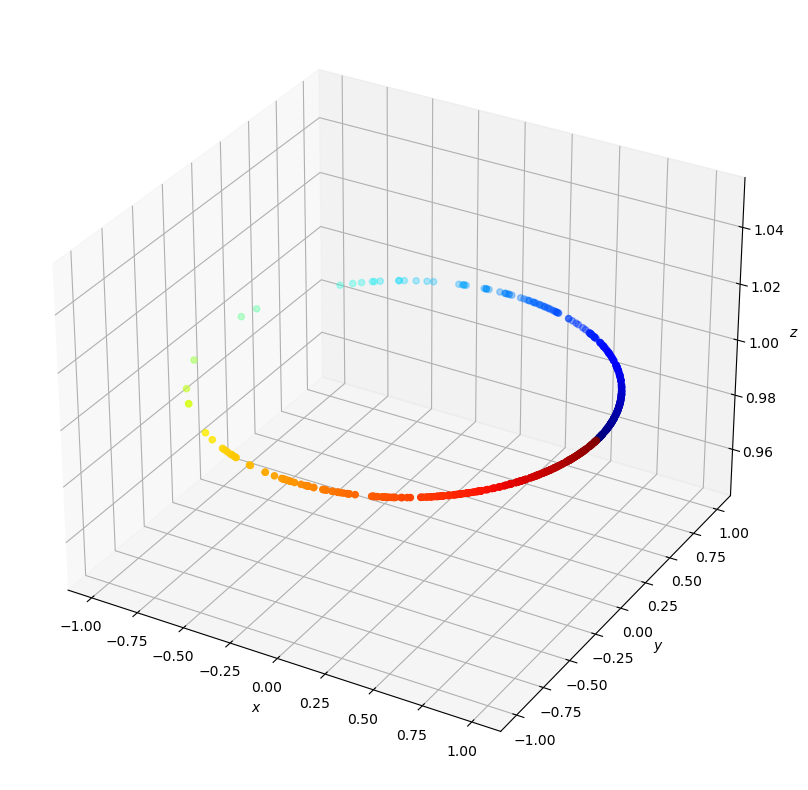

In [200]:
# Plot the dataset.
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.scatter(Xt[0],Xt[1],Xt[2],c=phiList,cmap="jet")
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')
plt.show()

In [201]:
poly = PolynomialFeatures(1)

In [202]:
B = poly.fit_transform(X)
B.shape

(512, 4)

In [203]:
#newB = np.hstack((X, X**2))

In [204]:
#newB.shape

In [205]:
#const = np.array([[1] for i in range(X.shape[0])])

In [206]:
#newB2 = np.hstack((const,X,X**2))

In [207]:
#newB2.shape

In [208]:
poly.get_feature_names_out()

array(['1', 'x0', 'x1', 'x2'], dtype=object)

In [209]:
poly.n_features_in_

3

In [210]:
def tryDim(B, d, n_epochs=5000):
    manifold_param = mnn.Parameter(manifold=mnn.Stiefel(B.shape[1],d))
    Btensor = torch.tensor(B).float()
    
    def model(mat):
        term1 = torch.matmul(Btensor, mat)
        #term2 = torch.norm(term1)
        #return term2
        return term1
    
    y = torch.zeros((B.shape[0],d))
    
    #optimizer = moptim.rAdagrad(params = [manifold_param], lr=1e-2)
    optimizer = moptim.rSGD(params = [manifold_param], lr=1e-2)
    criterion = torch.nn.MSELoss() #torch.nn.L1Loss() #torch.nn.MSELoss()
    for epoch in range(n_epochs):
        y_pred = model(manifold_param)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
    return loss.item(), manifold_param

In [211]:
t1 = tryDim(B,1)

In [212]:
t2 = tryDim(B,2)

In [213]:
t3 = tryDim(B,3)

In [214]:
costs = [0, t1[0], t2[0], t3[0]]
costs

[0, 7.1114373070835235e-12, 0.07598672062158585, 0.18538005650043488]

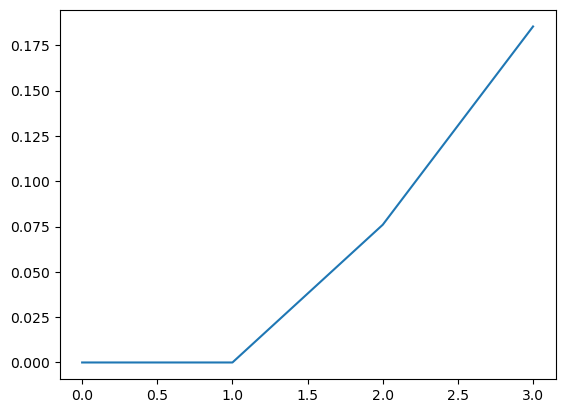

In [215]:
plt.plot([i+1 for i in range(-1,3)], costs)

In [216]:
t1[1]

Parameter containing:
tensor([[-7.0711e-01],
        [ 5.1296e-06],
        [-1.8212e-08],
        [ 7.0710e-01]], requires_grad=True)

In [217]:
A1 = np.array([t1[1][i].detach().numpy() for i in range(1,t1[1].shape[0])]).transpose()

In [218]:
A1

array([[ 5.1295738e-06, -1.8211878e-08,  7.0710444e-01]], dtype=float32)

In [219]:
A1.shape

(1, 3)

In [220]:
A2 = scipy.linalg.null_space(A1) #gives an O.N. basis.
A2

array([[ 2.5755568e-08, -1.0000000e+00],
       [ 1.0000000e+00,  2.5755382e-08],
       [ 2.5755382e-08,  7.2717667e-06]], dtype=float32)

In [221]:
NewX = X@A2

In [222]:
NewX.shape

(512, 2)

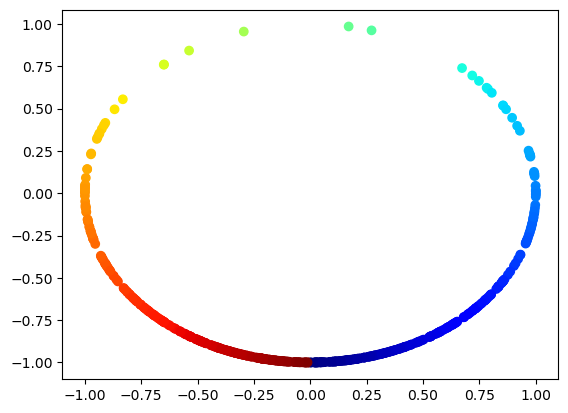

In [223]:
plt.scatter(NewX.transpose()[0], NewX.transpose()[1], c=phiList, cmap="jet")

In [224]:
poly2 = PolynomialFeatures(2)

In [225]:
B2 = poly2.fit_transform(NewX)

In [226]:
B2.shape

(512, 6)

In [227]:
poly2.get_feature_names_out()

array(['1', 'x0', 'x1', 'x0^2', 'x0 x1', 'x1^2'], dtype=object)

In [228]:
t1a = tryDim(B2,1)

In [229]:
t2a = tryDim(B2,2)

In [230]:
costsA = [t1a[0], t2a[0]]
costsA

[1.3457308796205325e-06, 0.021567033603787422]

In [231]:
t1a[1]

Parameter containing:
tensor([[-0.5770],
        [-0.0018],
        [ 0.0007],
        [ 0.5771],
        [-0.0044],
        [ 0.5779]], requires_grad=True)

In [279]:
class invf():
    def __init__(self,W,featFunc,X):
        self.ds = X
        self.params = W
        self.featFunc = featFunc
        self.B = self.featFunc.fit_transform(self.ds)
        
        
    def f(self,Y):
        w = self.params
        trans = self.featFunc.transform(Y)
        term = trans@w
        #term = w[0]*x[0]**2 + w[1]*x[0] + w[2]*x[1]**2 + w[3]*x[1] + w[4]*x[2]**2 + w[5]*x[2] + w[6] # missing x*y.
        return term
    
    
    def jacf(self,x): #Jacobian at a single point.
        #w = self.params
        dim = self.featFunc.n_features_in_
        from sympy import symbols
        from sympy import Matrix
        from sympy import lambdify
        # create sympy symbols.
        exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
        # Fix things: no x0^2 and such.
        p1 = ",".join(list(self.featFunc.get_feature_names_out()))
        p2 = p1.replace(" ", "*")
        p3 = p2.replace("^", "**")
        p3a = list(eval(p3))
        p4 = Matrix(p3a)
        # Define the jacobian and make it a numpy array.
        J = p4.jacobian(Matrix(p3a[1:dim+1]))
        #print(J)
        Jnp = lambdify([p3a[1:dim+1]],J)
        #print(self.params.transpose()@J)
        realJ = self.params.transpose()@Jnp(x)
        return realJ
    
    
    def Jacf(self,X): #stacked Jacobian matrix at each point in X
        #w = self.params
        dim = self.ds.shape[1] #self.featFunc.n_features_in_
        from sympy import symbols
        from sympy import Matrix
        from sympy import lambdify
        # create sympy symbols.
        #exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
        exec(",".join(self.featFunc.get_feature_names_out()[1:dim+1]) + '= symbols(" ".join(self.featFunc.get_feature_names_out()[1:dim+1]))')
        # Fix things: no x0^2 and such.
        p1 = ",".join(self.featFunc.get_feature_names_out())
        p2 = p1.replace(" ", "*")
        p3 = p2.replace("^", "**")
        p3a = eval(p3)
        p4 = Matrix(p3a)
        # Define the jacobian and make it a numpy array.
        J = p4.jacobian(Matrix(p3a[1:dim+1]))
        Jnp = lambdify([p3a[1:dim+1]],J)        
        
        
        jacs = []
        for x in X:
            #jacs.extend([self.params.transpose()@Jnp(x)])
            #jacs.extend([torch.matmul(torch.transpose(self.params), Jnp(x))])
            #print(torch.tensor(Jnp(x)))
            jacs.extend([torch.matmul(torch.transpose(torch.tensor(Jnp(x)).float(), 0, 1), self.params)])
            
        jacs = [torch.transpose(jac,0,1) for jac in jacs]
        #print(jacs[0].shape)
        bigJ = torch.stack(jacs, dim=0)
        #bigJ = np.array(jacs) #np.vstack(jacs)
        return bigJ
    
    
    def JacfSym(self,X): #stacked Jacobian matrix at each point in X
        #w = self.params
        dim = self.ds.shape[1] #self.featFunc.n_features_in_
        from sympy import symbols
        from sympy import Matrix
        from sympy import lambdify
        # create sympy symbols.
        #exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
        exec(",".join(self.featFunc.get_feature_names_out()[1:dim+1]) + '= symbols(" ".join(self.featFunc.get_feature_names_out()[1:dim+1]))')
        # Fix things: no x0^2 and such.
        p1 = ",".join(self.featFunc.get_feature_names_out())
        p2 = p1.replace(" ", "*")
        p3 = p2.replace("^", "**")
        p3a = eval(p3)
        p4 = Matrix(p3a)
        # Define the jacobian and make it a numpy array.
        J = p4.jacobian(Matrix(p3a[1:dim+1]))
        return J
  

    def Jac2f(self,X, ex=1): #stacked Jacobian matrix at each point in X
        #w = self.params
        dim = self.ds.shape[1] #self.featFunc.n_features_in_
        from sympy import symbols
        from sympy import Matrix
        from sympy import lambdify
        # create sympy symbols.
        #exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
        exec(",".join(self.featFunc.get_feature_names_out()[ex:dim+ex]) + '= symbols(" ".join(self.featFunc.get_feature_names_out()[ex:dim+ex]))')
        # Fix things: no x0^2 and such.
        p1 = ",".join(self.featFunc.get_feature_names_out())
        p2 = p1.replace(" ", "*")
        p3 = p2.replace("^", "**")
        p3a = eval(p3)
        p4 = Matrix(p3a)
        # Define the jacobian and make it a numpy array.
        J = p4.jacobian(Matrix(p3a[ex:dim+ex]))
        Jnp = lambdify([p3a[ex:dim+ex]],J)        
        
        
        jacs = []
        for x in X:
            #jacs.extend([self.params.transpose()@Jnp(x)])
            #jacs.extend([torch.matmul(torch.transpose(self.params), Jnp(x))])
            #print(torch.tensor(Jnp(x)))
            jacs.extend([torch.matmul(torch.transpose(torch.tensor(Jnp(x)).float(), 0, 1), self.params)])
            
        jacs = [torch.transpose(jac,0,1) for jac in jacs]
        #print(jacs[0].shape)
        bigJ = torch.stack(jacs, dim=0)
        #bigJ = np.array(jacs) #np.vstack(jacs)
        return bigJ


    
    def getfunc(self):
        return self.f
    
    
    def getgrad(self):
        return self.gradf
    
    
    def getParams(self):
        return self.params
    
    
    def getDS(self):
        return self.ds

In [233]:
myf = invf(t1a[1], poly2, NewX)

In [234]:
myJ = myf.Jacf(NewX)

In [235]:
myJ.shape

torch.Size([512, 1, 2])

In [236]:
mySymJ = myf.JacfSym(NewX)

In [237]:
import sympy

In [238]:
newMat = sympy.Matrix(myf.params.detach().numpy())

In [239]:
newMat

Matrix([
[   -0.57704],
[-0.00181786],
[0.000706471],
[   0.577089],
[-0.00437906],
[   0.577901]])

In [240]:
nt2 = sympy.transpose(newMat) * mySymJ

In [241]:
nt2

Matrix([[1.15418*x0 - 0.00437906*x1 - 0.00181786, -0.00437906*x0 + 1.1558*x1 + 0.000706471]])

In [242]:
nt2.shape

(1, 2)

In [243]:
NullSp = nt2.nullspace()

In [244]:
len(NullSp)

1

In [245]:
NullSp[0]

Matrix([
[-(-0.00437906*x0 + 1.1558*x1 + 0.000706471)/(1.15418*x0 - 0.00437906*x1 - 0.00181786)],
[                                                                                    1]])

In [246]:
sympy.denom(NullSp[0][0]) * NullSp[0]

Matrix([
[0.00437906*x0 - 1.1558*x1 - 0.000706471],
[1.15418*x0 - 0.00437906*x1 - 0.00181786]])

In [247]:
# This is a memory hog. Can we fix this later?
def getExtendedFeatureMatrix2(B,J,dim):
    n = B.shape[0]
    m = B.shape[1]
    ExtArray = []
    for j in range(n):
        newBthing = np.append(B[j],np.zeros((dim-1)*m))
        Barray = np.array([np.roll(newBthing,i*m) for i in range(dim)])
        Barray = torch.tensor(Barray).float()
        thing = torch.matmul(J[j], Barray)
        #thing = np.dot(J[j],Barray)
        ExtArray.extend(thing)
        
    ExtArray = torch.stack(ExtArray, dim=0)
    #ExtArray = np.array(ExtArray)
    return ExtArray

In [248]:
def tryDimV(extB, d, n_epochs=1000):
    manifold_param = mnn.Parameter(manifold=mnn.Stiefel(extB.shape[1],d))
    Btensor = extB.detach() #torch.tensor(B).float()
    
    def model(mat):
        term1 = torch.matmul(Btensor, mat)
        #term2 = torch.norm(term1)
        #return term2
        return term1
    
    y = torch.zeros((B.shape[0],d))
    
    #optimizer = moptim.rAdagrad(params = [manifold_param], lr=1e-2)
    optimizer = moptim.rSGD(params = [manifold_param], lr=1e-2)
    criterion = torch.nn.MSELoss() #torch.nn.L1Loss() #torch.nn.MSELoss()
    for epoch in range(n_epochs):
        y_pred = model(manifold_param)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
    return loss.item(), manifold_param

In [249]:
def tryIt(degree, its, NewX, myJ, inc = True):
    poly3 = PolynomialFeatures(degree, include_bias=inc)
    B3 = poly3.fit_transform(NewX)
    extB3 = getExtendedFeatureMatrix2(B3,myJ,2)
    ans = []
    for i in range(its):
        T = tryDimV(extB3, i+1)
        ans.extend([T])
        
    return ans

[0, 0.5355713367462158, 0.6664414405822754]


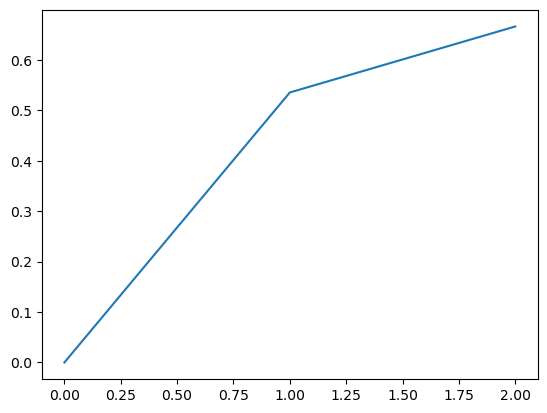

In [250]:
its = 2
T0a = tryIt(0,its,NewX,myJ,inc=True)
costs0=[0]
costs0.extend([T0a[i][0] for i in range(its)])
print(costs0)
plt.plot([i+1 for i in range(-1,its)], costs0)

[0, 1.0981080777128227e-05, 0.15356609225273132]


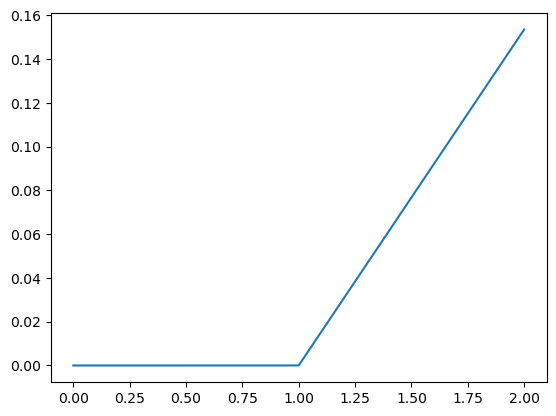

In [251]:
its = 2
T1a = tryIt(1,its,NewX,myJ,inc=False)
costs1=[0]
costs1.extend([T1a[i][0] for i in range(its)])
print(costs1)
plt.plot([i+1 for i in range(-1,its)], costs1)

[0, 0.014943009242415428, 0.08591269701719284]


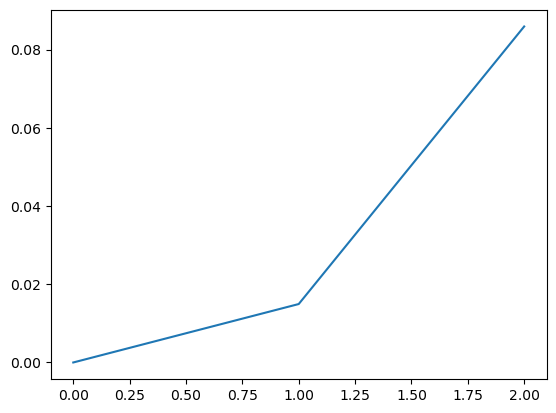

In [252]:
its = 2
T1b = tryIt(1,its,NewX,myJ,inc=True)
costs1b=[0]
costs1b.extend([T1b[i][0] for i in range(its)])
print(costs1b)
plt.plot([i+1 for i in range(-1,its)], costs1b)

[0, 0.008991644717752934, 0.008501142263412476]


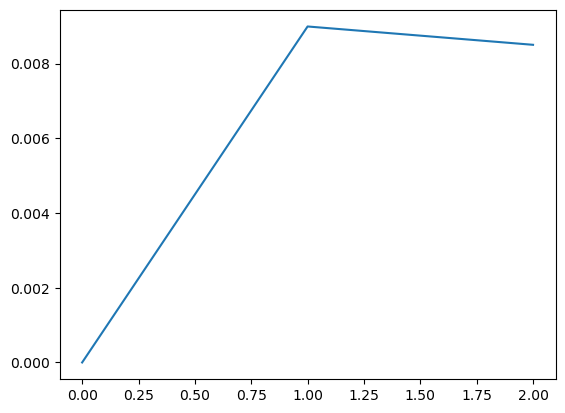

In [253]:
its = 2
T2a = tryIt(2,its,NewX,myJ,inc=True)
costs2=[0]
costs2.extend([T2a[i][0] for i in range(its)])
print(costs2)
plt.plot([i+1 for i in range(-1,its)], costs2)

In [254]:
T1a[0]

(1.0981080777128227e-05,
 Parameter containing:
 tensor([[-0.0066],
         [ 0.7047],
         [-0.7095],
         [ 0.0038]], requires_grad=True))

In [255]:
T1b[0]

(0.014943009242415428,
 Parameter containing:
 tensor([[-0.0682],
         [ 0.0197],
         [-0.6607],
         [ 0.3571],
         [ 0.5220],
         [ 0.3980]], requires_grad=True))

In [256]:
T2a

[(0.008991644717752934,
  Parameter containing:
  tensor([[ 0.0366],
          [-0.0483],
          [-0.1425],
          [-0.0097],
          [-0.1462],
          [ 0.3059],
          [ 0.2104],
          [-0.1933],
          [ 0.2473],
          [-0.1358],
          [-0.8344],
          [ 0.0593]], requires_grad=True)),
 (0.008501142263412476,
  Parameter containing:
  tensor([[-0.0419, -0.3125],
          [ 0.0298, -0.1515],
          [ 0.0430,  0.3529],
          [ 0.0222,  0.3248],
          [ 0.3725, -0.4591],
          [ 0.3387,  0.3730],
          [-0.4644,  0.0813],
          [ 0.2125, -0.4169],
          [ 0.1666,  0.2248],
          [ 0.2740, -0.0373],
          [ 0.0701, -0.1609],
          [ 0.6107,  0.2033]], requires_grad=True))]

In [280]:
def TRYDIM(V, X, Bv, polyM, d, EX=1, n_epochs=100):
    
    # This is a memory hog. Can we fix this later?
    def getExtendedFeatureMatrix2(B,J,dim):
        n = B.shape[0]
        m = B.shape[1]
        ExtArray = []
        for j in range(n):
            newBthing = np.append(B[j],np.zeros((dim-1)*m))
            Barray = np.array([np.roll(newBthing,i*m) for i in range(dim)])
            Barray = torch.tensor(Barray).float()
            thing = torch.matmul(J[j], Barray)
            #thing = np.dot(J[j],Barray)
            ExtArray.extend(thing)
        
        ExtArray = torch.stack(ExtArray, dim=0)
        #ExtArray = np.array(ExtArray)
        return ExtArray
    
    
    B0 = polyM.fit(X)
    def model(mat):
        Invf = invf(mat,polyM,X)
        J = Invf.Jac2f(Invf.ds,ex=EX)
        #B = Invf.featFunc.fit_transform(Invf.ds)
        extB = getExtendedFeatureMatrix2(Bv,J,dim=2)
        #extB = torch.tensor(extB).float()
        #print(Bt.shape)
        #print(V.shape)
        term1 = torch.matmul(extB, V)
        #print(term1.shape)
        #print(J.shape)
        #term2 = torch.matmul(term1, torch.transpose(J.reshape((J.shape[0],J.shape[2])),0,1))
        return term1
    
    manifold_param = mnn.Parameter(manifold=mnn.Stiefel(polyM.n_output_features_,d))    
    
    y = torch.zeros((X.shape[0],d))
    
    #optimizer = moptim.rAdagrad(params = [manifold_param], lr=1e-2)
    optimizer = moptim.rSGD(params = [manifold_param], lr=1e-2)
    criterion = torch.nn.MSELoss() #torch.nn.L1Loss() #torch.nn.MSELoss()
    for epoch in range(n_epochs):
        y_pred = model(manifold_param)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
    return loss.item(), manifold_param #model(manifold_param).item()

In [313]:
poly3 = PolynomialFeatures(2,include_bias=False)
poly3b = PolynomialFeatures(3,include_bias=False)
Poly3 = PolynomialFeatures(1,include_bias=False)
Poly3b = PolynomialFeatures(2)

In [274]:
B3 = Poly3.fit_transform(NewX) #= poly3.fit_transform(NewX)
B3b = Poly3b.fit_transform(NewX)

In [288]:
x1 = TRYDIM(T1a[0][1].detach(), NewX, B3, poly3, 1, EX=0, n_epochs=2000)

In [289]:
x1

(0.0009643397643230855,
 Parameter containing:
 tensor([[-0.0088],
         [-0.0886],
         [ 0.7392],
         [-0.0185],
         [ 0.6673]], requires_grad=True))

In [295]:
x2 = TRYDIM(T2a[0][1].detach(), NewX, B3b, poly3b, 1, EX=0, n_epochs=2000)

In [296]:
x2

(0.00915835052728653,
 Parameter containing:
 tensor([[-0.3323],
         [ 0.0481],
         [-0.1730],
         [-0.5585],
         [-0.0816],
         [ 0.1926],
         [-0.6170],
         [-0.2722],
         [-0.2166]], requires_grad=True))

In [297]:
ex1 = x1[1].detach().numpy()
ex1 = ex1.reshape(ex1.shape[0])

In [314]:
myF = invf(ex1,poly3,NewX)

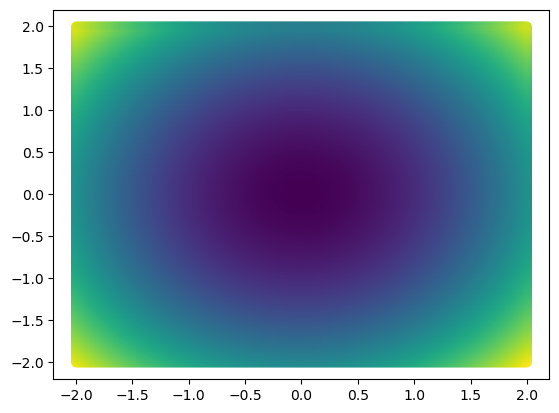

In [316]:
xs = np.linspace(-2,2,400)
Xs, Ys = np.meshgrid(xs, xs)
grid = np.vstack([Xs.ravel(), Ys.ravel()])
gridT = grid.transpose()
PsuProbs = myF.f(np.array([grid[0],grid[1]]).transpose())
plt.scatter(grid[0], grid[1], c=PsuProbs)